In [1]:
from eval import Evaluator
from training import Trainer
import models
import pandas as pd
import os
from types import SimpleNamespace

from models import Linear, TimesNet, Transformer, DLinear, AutoEncoder
from tqdm import tqdm

import numpy as np
import torch
import random
from vus_torch import VUSTorch
import tools
from procedure import train_and_evaluate, compare_reconstruction
import matplotlib.pyplot as plt

In [2]:

seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

path = '../Datasets/TSB-AD-U/'
file_list = '../Datasets/File_List/TSB-AD-U-Eva-Full.csv'
file_list = pd.read_csv(file_list)['file_name'].values

win_size = 32



trainer = Trainer(
    batch_size=1024,
    lr=1e-3,
    device='cuda',
    win_size=win_size,
    validation_size=0.2
)
evaluator = Evaluator(
    batch_size=1024,
    device='cuda',
    metrics='all',
    strategy='overlapping'
)


In [3]:
config = SimpleNamespace(
    seq_len=win_size,
)
model = Linear.Model(config)





config = SimpleNamespace(
    task_name='anomaly_detection',
    seq_len=win_size,
    label_len=win_size,  # unused
    pred_len=0,   # no forecasting for reconstruction
    enc_in=1,      # univariate input
    moving_avg=15,
)

In [4]:
config = SimpleNamespace(
    task_name='anomaly_detection',
    seq_len=win_size,
    label_len=win_size,  # unused
    pred_len=0,   # no forecasting for reconstruction
    top_k=3,
    d_model=8,
    d_ff=16,       
    num_kernels=6, # number of kernels in InceptionBlock
    e_layers=1,    # number of TimesNet blocks
    embed='timeF',  
    freq='t',       
    dropout=0.1,   # dropout rate
    enc_in=1,      # univariate input
    c_out=1,       # univariate output 
)


filename = file_list[0]
model = TimesNet.Model(config)
metrics = train_and_evaluate(
            path,
            filename,
            model,
            trainer,
            evaluator,
            win_size=win_size,
            epochs=500
        )
data_train, data, label = tools.read_file(path, filename)
reconstruction = evaluator.overlapping_reconstruct(data, model, win_size, 1).cpu()

relative_error = evaluator.relative_reconstruction_error(
            data, model, win_size)

rel_erruer_normal = relative_error[label == 0].mean()
rel_erreur_anomalie = relative_error[label == 1].mean()
top_1_normal = relative_error[label == 0].max()
top_1_anomalie = relative_error[label == 1].max()

print(f"Mean relative error (normal): {rel_erruer_normal.item():.4f}")
print(f"Mean relative error (anomalie): {rel_erreur_anomalie.item():.4f}")
print(f"Max relative error (normal): {top_1_normal.item():.4f}")
print(f"Max relative error (anomalie): {top_1_anomalie.item():.4f}")
metrics['AUC-PR'].round(3), metrics['AUC-ROC'].round(3), metrics['Standard-F1'].round(3)

Mean relative error (normal): 0.0183
Mean relative error (anomalie): 0.1302
Max relative error (normal): 0.4899
Max relative error (anomalie): 0.3553


(0.123, 0.962, 0.308)

In [5]:
filename

'438_UCR_id_136_Medical_tr_14750_1st_57960.csv'

In [6]:
metrics['AUC-PR'].round(3), metrics['AUC-ROC'].round(3), metrics['Standard-F1'].round(3)

(0.123, 0.962, 0.308)

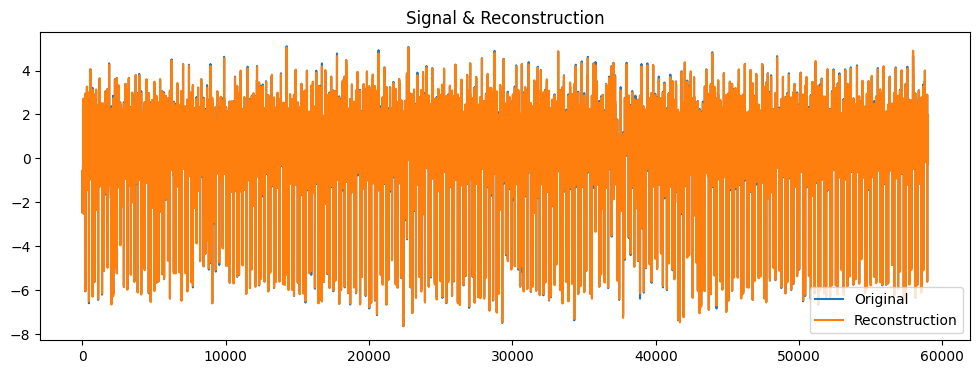

Text(0.5, 1.0, 'Reconstruction Error with Abnormal Labels')

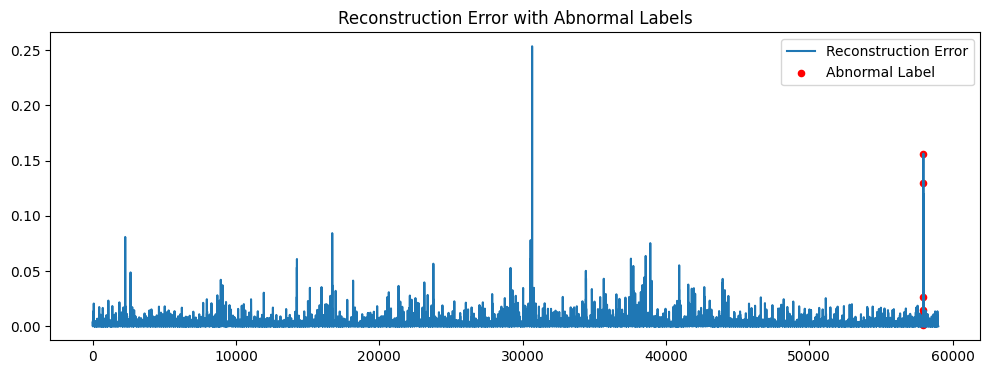

In [7]:
plt.figure(figsize=(12,4))
plt.plot(data, label='Original')
plt.plot(reconstruction, label='Reconstruction')
plt.legend()
plt.title("Signal & Reconstruction")
#plt.xlim(30000,33000)
plt.show()

# Reconstruction error
reconstruction_error = evaluator.reconstruction_error(data, model, win_size)
#reconstruction_error /= np.max(reconstruction_error)

plt.figure(figsize=(12,4))
plt.plot(reconstruction_error, label='Reconstruction Error')

# --- Highlight abnormal labels ---
anomaly_indices = np.where(label == 1)[0]
plt.scatter(anomaly_indices,
            reconstruction_error[anomaly_indices],
            color='red', s=20, label='Abnormal Label')

plt.legend()
plt.title("Reconstruction Error with Abnormal Labels")

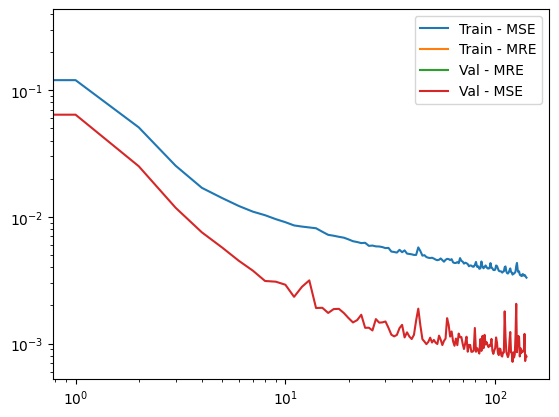

In [8]:
plt.plot(trainer.train_losses, label = "Train - MSE")
plt.plot(trainer.train_relative_losses, label = "Train - MRE")
plt.plot(trainer.val_relative_losses, label = "Val - MRE")
plt.plot(trainer.val_losses, label = "Val - MSE")
plt.yscale("log")
plt.xscale("log")
plt.legend()
#plt.savefig("AdamW_no_scheduler_decay2.png")
plt.show()

In [9]:
trainer.early_stop_epoch

141

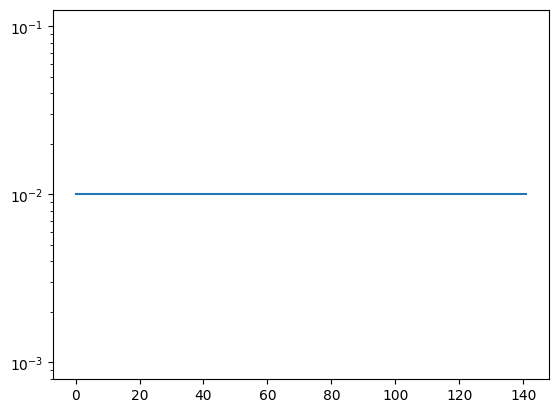

In [10]:
plt.plot(trainer.lrs)
plt.yscale("log")

In [11]:
pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
pytorch_total_params

73449

In [12]:
reconstruction_error = evaluator.reconstruction_error(data, model, win_size)
maxi = np.max(reconstruction_error)
mini = np.min(reconstruction_error)
reconstruction_error = ( reconstruction_error - mini) / (maxi-mini)
reconstruction_error = np.round(reconstruction_error, 2)

In [13]:
vus = VUSTorch(slope_size=128, device='cuda')

In [14]:
value, timing = vus.compute(torch.from_numpy(label).to("cuda"), torch.from_numpy(reconstruction_error).to("cuda"))
value, timing

((tensor(0.2167, device='cuda:0'),
  {'Anomaly coordinates time': 0.004452705383300781,
   'Safe mask time': 0.0005519390106201172,
   'Thresholds time': 0.00043582916259765625,
   'Score mask time': 0.0001125335693359375,
   'Position time': 0.000118255615234375,
   'Slopes time': 0.0003154277801513672,
   'Existence time': 0.0002465248107910156,
   'Confusion matrix time': 0.00044226646423339844,
   'Precision recall curve time': 0.0001289844512939453,
   'Integral time': 5.269050598144531e-05}),
 0.008980751037597656)

In [15]:
value[0]

tensor(0.2167, device='cuda:0')

In [16]:
metrics

{'AUC-PR': 0.1230099428147459,
 'AUC-ROC': 0.9620647567384303,
 'VUS-PR': 0.007402019896585731,
 'VUS-ROC': 0.9714924206370755,
 'Standard-F1': 0.3076887574374142,
 'PA-F1': 0.9523809523809523,
 'Event-based-F1': 0.7999999999999995,
 'R-based-F1': 0.3943661971830986,
 'Affiliation-F': 0.9360384864361299}